# Starbucks Northern Mexico Market-Entry Strategy

**Case question:** Should Starbucks Mexico pursue a staged 30-store expansion across Monterrey, Tijuana, Saltillo, Chihuahua and Hermosillo?

The project separates sourced facts from commercial assumptions:

- **Sourced:** 2020 metropolitan populations, 2024 state GDP shares, Alsea operating context and Starbucks Mexico store milestones.
- **Assumed:** purchasing-power index, saturation headroom, strategic fit, ticket, traffic, margin, capex, ramp and cannibalization.

This is an independent student case, not a Starbucks or Alsea plan.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path.cwd()
DATA = BASE / 'data'
CHARTS = BASE / 'charts'
CHARTS.mkdir(exist_ok=True)

cities = pd.read_csv(DATA / 'northern_mexico_city_inputs.csv')
cities

,City,State,Population_m,State_GDP_Share,Income_Index,Headroom_Index,Strategic_Fit,Planned_Stores
0,Monterrey,Nuevo Leon,5.341177,0.081,100,70,95,10
1,Tijuana,Baja California,2.157853,0.039,92,85,90,8
2,Saltillo,Coahuila,1.031779,0.037,88,90,82,5
3,Chihuahua,Chihuahua,0.988065,0.038,84,88,78,4
4,Hermosillo,Sonora,0.936263,0.033,86,90,80,3


## 1. City attractiveness score

Weights:

- Metro population: 35%
- State GDP share: 20%
- Premium-income index: 20%
- Saturation headroom: 15%
- Strategic fit: 10%

The final three inputs are explicit assumptions. Site-level economics should ultimately override city averages.

In [2]:
def minmax(series):
    lo, hi = series.min(), series.max()
    return pd.Series(50, index=series.index) if hi == lo else 100*(series-lo)/(hi-lo)

cities['Population_Score'] = minmax(cities['Population_m'])
cities['GDP_Score'] = minmax(cities['State_GDP_Share'])
cities['Weighted_Score'] = (
    cities['Population_Score']*0.35 +
    cities['GDP_Score']*0.20 +
    cities['Income_Index']*0.20 +
    cities['Headroom_Index']*0.15 +
    cities['Strategic_Fit']*0.10
)
cities['Rank'] = cities['Weighted_Score'].rank(ascending=False, method='min').astype(int)
cities.sort_values('Rank')[['City','Weighted_Score','Rank','Planned_Stores']]

,City,Weighted_Score,Rank,Planned_Stores
0,Monterrey,95.000000,1,10
1,Tijuana,52.356353,2,8
2,Saltillo,41.725605,3,5
3,Chihuahua,40.294935,4,4
4,Hermosillo,38.700000,5,3


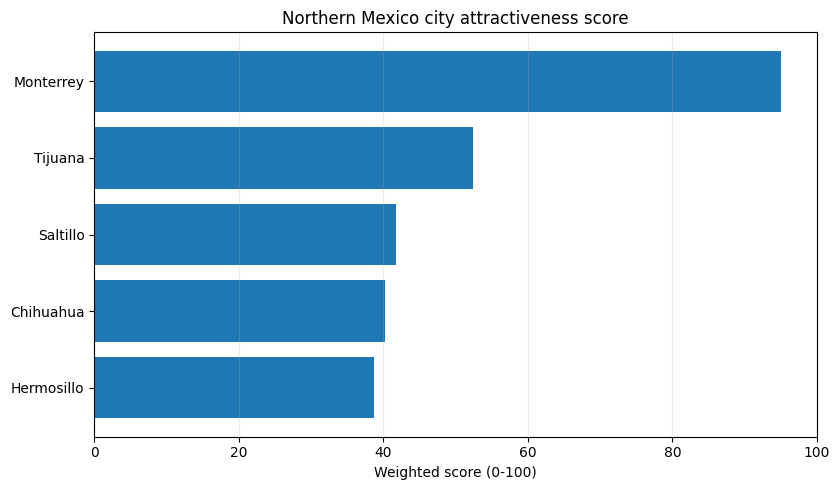

In [3]:
fig, ax = plt.subplots(figsize=(8.5,5))
plot_df = cities.sort_values('Weighted_Score')
ax.barh(plot_df['City'], plot_df['Weighted_Score'])
ax.set_title('Northern Mexico city attractiveness score')
ax.set_xlabel('Weighted score (0-100)')
ax.set_xlim(0,100)
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(CHARTS / 'starbucks_city_score.png', dpi=200, bbox_inches='tight')
plt.show()

## 2. Unit economics and staged rollout

Base assumptions are intentionally editable:

- Average ticket: MXN 135
- Mature transactions/day: 420
- Operating days: 360
- Store EBITDA margin: 22%
- Opening capex: MXN 10m/store
- Cannibalization: 4%
- Maintenance capex: 2% of revenue
- Cash tax proxy: 30%
- Store ramp: 65%, 85%, 100%, then 4% annual same-store growth

Rollout: 10 stores in each of Years 1-3.

In [4]:
ticket = 135.0
transactions = 420
operating_days = 360
store_ebitda_margin = 0.22
opening_capex = 10.0
maintenance_capex_pct = 0.02
tax_rate = 0.30
cannibalization = 0.04
discount_rate = 0.12
terminal_growth = 0.03
ramp = np.array([0.65,0.85,1.00,1.04,1.0816])
new_stores = np.array([10,10,10,0,0])

mature_revenue = ticket*transactions*operating_days/1_000_000*(1-cannibalization)
revenues = np.zeros(5)
for cohort_year in range(3):
    stores = new_stores[cohort_year]
    for year in range(cohort_year,5):
        age = year-cohort_year
        revenues[year] += stores*mature_revenue*ramp[age]

ebitda = revenues*store_ebitda_margin
cash_tax = ebitda*tax_rate
maintenance_capex = revenues*maintenance_capex_pct
opening_capex_by_year = new_stores*opening_capex
cash_flow = ebitda-cash_tax-maintenance_capex-opening_capex_by_year
cumulative_cf = np.cumsum(cash_flow)
discount_factors = np.array([1/(1+discount_rate)**i for i in range(1,6)])
pv_stage = cash_flow*discount_factors
terminal_value = cash_flow[-1]*(1+terminal_growth)/(discount_rate-terminal_growth)
pv_terminal = terminal_value*discount_factors[-1]
npv_ex_terminal = pv_stage.sum()
npv_incl_terminal = npv_ex_terminal + pv_terminal

model = pd.DataFrame({
    'Year':[1,2,3,4,5],
    'New_Stores':new_stores,
    'Revenue_MXNm':revenues,
    'Store_EBITDA_MXNm':ebitda,
    'Opening_Capex_MXNm':opening_capex_by_year,
    'Unlevered_CF_MXNm':cash_flow,
    'Cumulative_CF_MXNm':cumulative_cf,
    'PV_MXNm':pv_stage,
})
print(f'Mature revenue per store: MXN {mature_revenue:.1f}m')
print(f'Mature cash contribution per store: MXN {(mature_revenue*store_ebitda_margin*(1-tax_rate)-mature_revenue*maintenance_capex_pct):.1f}m')
print(f'5-year NPV excluding terminal value: MXN {npv_ex_terminal:.1f}m')
print(f'PV of terminal value: MXN {pv_terminal:.1f}m')
print(f'NPV including terminal value: MXN {npv_incl_terminal:.1f}m')
model.round(1)

Mature revenue per store: MXN 19.6m
Mature cash contribution per store: MXN 2.6m
5-year NPV excluding terminal value: MXN -52.1m
PV of terminal value: MXN 532.3m
NPV including terminal value: MXN 480.2m


,Year,New_Stores,Revenue_MXNm,Store_EBITDA_MXNm,Opening_Capex_MXNm,Unlevered_CF_MXNm,Cumulative_CF_MXNm,PV_MXNm
0,1,10,127.4,28.0,100.0,-82.9,-82.9,-74.0
1,2,10,293.9,64.7,100.0,-60.6,-143.5,-48.3
2,3,10,489.9,107.8,100.0,-34.4,-177.9,-24.5
3,4,0,566.3,124.6,0.0,75.9,-102.0,48.2
4,5,0,611.7,134.6,0.0,82.0,-20.0,46.5


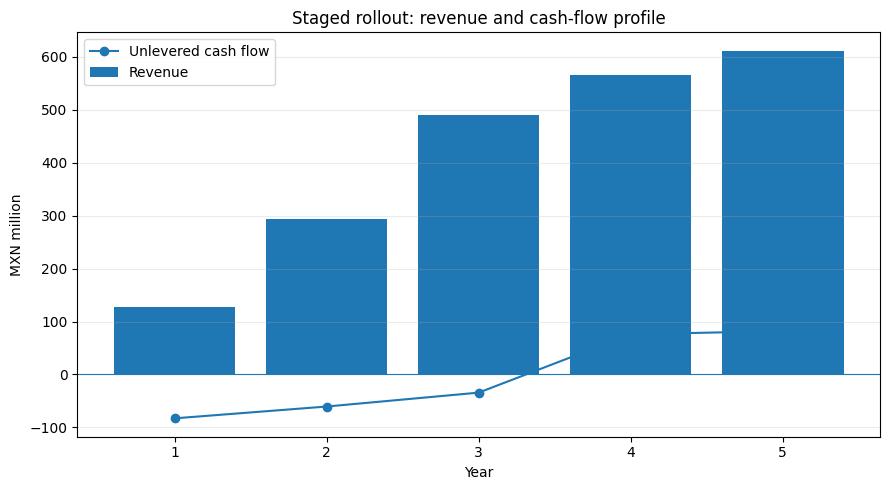

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(model['Year'], model['Revenue_MXNm'], label='Revenue')
ax.plot(model['Year'], model['Unlevered_CF_MXNm'], marker='o', label='Unlevered cash flow')
ax.axhline(0, linewidth=0.8)
ax.set_title('Staged rollout: revenue and cash-flow profile')
ax.set_xlabel('Year')
ax.set_ylabel('MXN million')
ax.grid(axis='y', alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(CHARTS / 'starbucks_rollout_economics.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Ticket and traffic sensitivity

A robust recommendation should not depend on one precise traffic forecast. The matrix below shows mature annual store cash contribution under alternative average tickets and transactions/day.

In [6]:
tickets = np.array([115,125,135,145,155])
traffic = np.array([320,370,420,470,520])
sens = pd.DataFrame(index=traffic, columns=tickets, dtype=float)
for t in traffic:
    for p in tickets:
        revenue = p*t*operating_days/1_000_000*(1-cannibalization)
        contribution = revenue*store_ebitda_margin*(1-tax_rate)-revenue*maintenance_capex_pct
        sens.loc[t,p] = contribution
sens.index.name = 'Transactions/day'
sens.columns.name = 'Average ticket (MXN)'
sens.round(2)

Average ticket (MXN),115,125,135,145,155
Transactions/day,,,,,
320,1.70,1.85,2.00,2.15,2.30
370,1.97,2.14,2.31,2.48,2.66
420,2.24,2.43,2.63,2.82,3.01
470,2.50,2.72,2.94,3.16,3.37
520,2.77,3.01,3.25,3.49,3.73


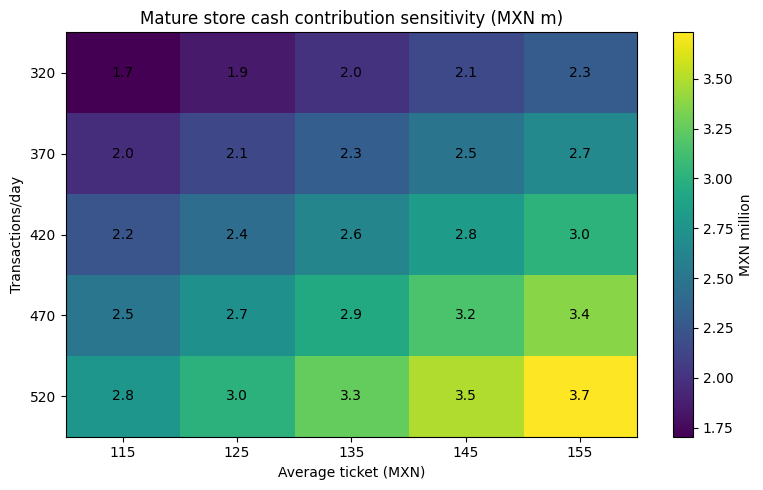

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
im = ax.imshow(sens.values.astype(float), aspect='auto')
ax.set_xticks(range(len(sens.columns)), sens.columns)
ax.set_yticks(range(len(sens.index)), sens.index)
ax.set_xlabel('Average ticket (MXN)')
ax.set_ylabel('Transactions/day')
ax.set_title('Mature store cash contribution sensitivity (MXN m)')
for i in range(sens.shape[0]):
    for j in range(sens.shape[1]):
        ax.text(j,i,f'{sens.iloc[i,j]:.1f}',ha='center',va='center')
fig.colorbar(im, ax=ax, label='MXN million')
fig.tight_layout()
fig.savefig(CHARTS / 'starbucks_unit_economics_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()

## Recommendation and stage gates

**Recommendation:** proceed with a staged pilot, not an unconditional 30-store commitment.

1. Build the first cluster in **Monterrey** and the second in **Tijuana**.
2. Use **Saltillo** as a lower-risk adjacency to the Monterrey operating cluster.
3. Gate **Chihuahua** and **Hermosillo** expansion on 12-month evidence.
4. Continue only when stores reach at least 90% of modeled sales ramp, at least 18% store EBITDA margin and no more than 8% cluster cannibalization.

The five-year cash flows remain negative before terminal value because stores require up-front capex and have long economic lives. Including a continuing-value assumption makes the long-term case positive, but that result is highly sensitive to traffic, ticket, margins, store life and discount rate. This is why the model recommends **stage gates** rather than pretending the city ranking is sufficient.